E4 Intermediate

Brian Bannon

This report presents a comprehensive quality analysis of one week of brake rotor production using Statistical Process Control (SPC) methods. The goal is to monitor process stability, detect trends, and identify sources of variation across machines, operators, and shifts. By leveraging Python-based visualizations and dashboards, this analysis provides actionable insights to prevent out-of-spec parts, improve process consistency, and support data-driven decision-making in a high-volume manufacturing environment.

In [237]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [238]:
def detect_trend(data: pd.DataFrame, measurement_column: str, threshold:float=0.005) -> str:
    """
    Function to detect trend in a measurement column over time
    :param data: pandas DataFrame containing production measurements
    :param measurement_column: name of the column to analyze (e.g., 'Thickness_mm')
    :param threshold: minimum difference between early and late averages to classify a trend (default = 0.005)
    :return: string indicating trend direction: 'Increasing', 'Decreasing', or 'Stable'
    """
    column = data[measurement_column]
    start = column.iloc[:1000].mean()
    end = column.iloc[-1000:].mean()
    difference = end - start
    if difference > threshold:
        return 'Increasing'
    elif difference < -threshold:
        return 'Decreasing'
    return 'Stable'

In [239]:
def create_control_chart(data: pd.DataFrame, measurement_column: str, lower_spec: float, upper_spec: float, title: str) -> None:
    """
    
    """
    
    y = data[measurement_column]
    x = range(len(y))
    plt.figure(figsize=(10, 5))
    plt.scatter(x, y, alpha=0.6, s=6, label='Measurements')
    
    plt.axhline(lower_spec, color='red', linestyle='--', label='Spec limits')
    plt.axhline(upper_spec, color='red', linestyle='--')

    plt.xlabel('Part number')
    plt.ylabel(measurement_column)
    plt.title(title)
    plt.legend()
    plt.grid()

In [240]:
def create_measurement_analysis_dashboard(data: pd.DataFrame, measurement_column: str, spec_limits: list) -> None:
    """
    Function to create a 2x2 dashboard of quality analysis visualizations
    :param data: pandas DataFrame containing production measurements
    :param measurement_column: name of the column to analyze (e.g., 'Thickness_mm')
    :param spec_limits: list containing [lower_spec, upper_spec] limits for the measurement
    :return: None (displays a dashboard including control chart, histogram, box plot, violin plot, and strip plot)
    """
    
    lower, upper = spec_limits
    column = data[measurement_column]
    part_numbers = range(len(column))

    _, axes = plt.subplots(2, 2, figsize=(14, 6))

    ax = axes[0, 0]
    ax.scatter(part_numbers, column, alpha=0.6, s=6, label='Measurements')
    ax.axhline(lower, color='red', linestyle='--', linewidth=2, label='Spec limits')
    ax.axhline(upper, color='red', linestyle='--', linewidth=2)
    ax.set_title('Process Stability')
    ax_hist = ax.twinx()
    counts, _, _ = ax_hist.hist(column, 30, color='blue')
    ax_hist.legend(loc='upper right')
    ax.legend()
    ax.grid()
    ax.set_xlabel('Part number')
    ax.set_ylabel(measurement_column)

    sns.boxplot(data, x='Machine_ID', y=measurement_column, ax=axes[0, 1])
    axes[0, 1].set_title('Machine Performance')
    axes[0, 1].set_xlabel('Machine ID')
    axes[0, 1].set_ylabel(measurement_column)

    sns.violinplot(data, x='Operator_ID', y=measurement_column, ax=axes[1, 0])
    axes[1, 0].set_title('Operator Consistency')
    axes[1, 0].set_xlabel('Operator ID')
    axes[1, 0].set_ylabel(measurement_column)

    sns.stripplot(data, x='Shift', y=measurement_column, size=2, ax=axes[1, 1], alpha=0.2)
    axes[1, 1].set_title('Shift Density')
    axes[1, 1].set_xlabel('Shift')
    axes[1, 1].set_ylabel(measurement_column)

    plt.tight_layout()
    plt.show()

In [241]:
data = pd.read_csv('E4_brake_rotor_production.csv')
specs_dict = {
    'Thickness_mm': (11.95, 12.05),
    'Diameter_mm': (299.8, 300.2),
    'Surface_Roughness_um': (0, 1.6),
    'Runout_mm': (0, 0.03)
}
for i in specs_dict:
    print(i, detect_trend(data, i))

Thickness_mm Stable
Diameter_mm Decreasing
Surface_Roughness_um Increasing
Runout_mm Stable


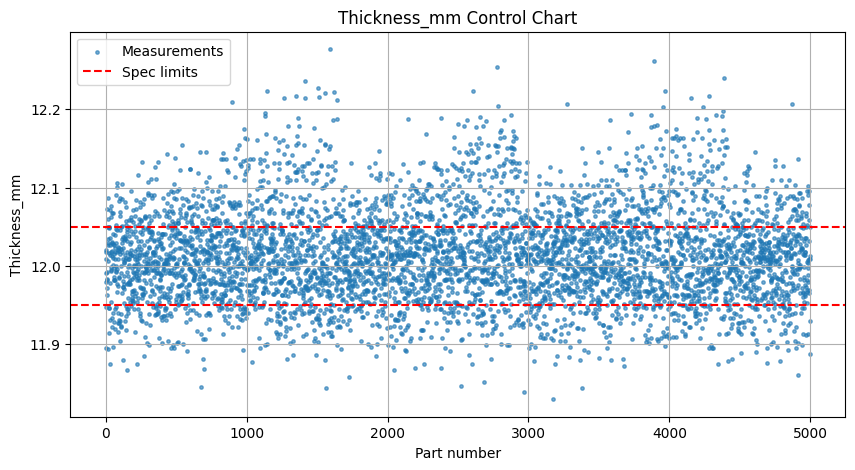

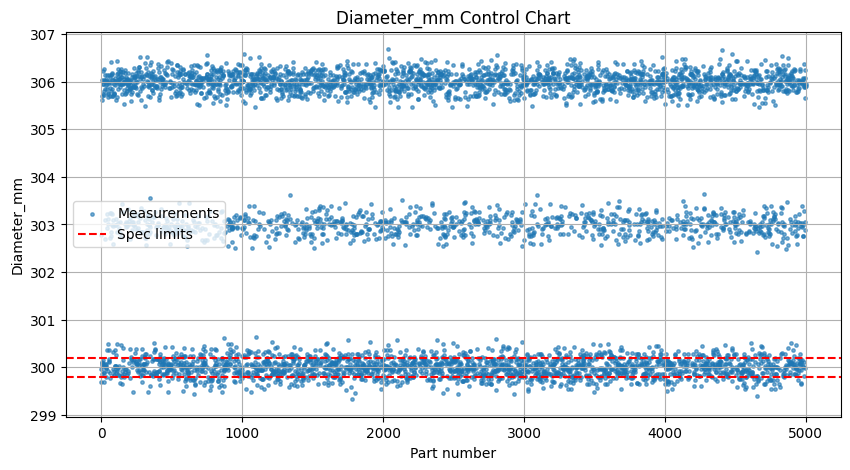

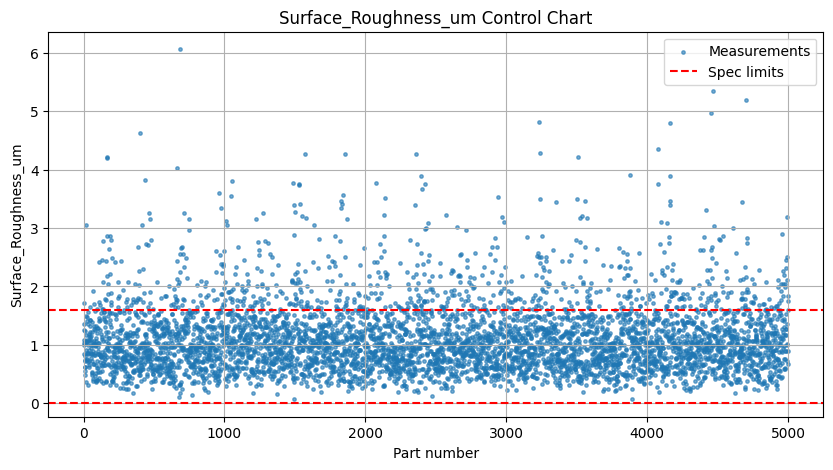

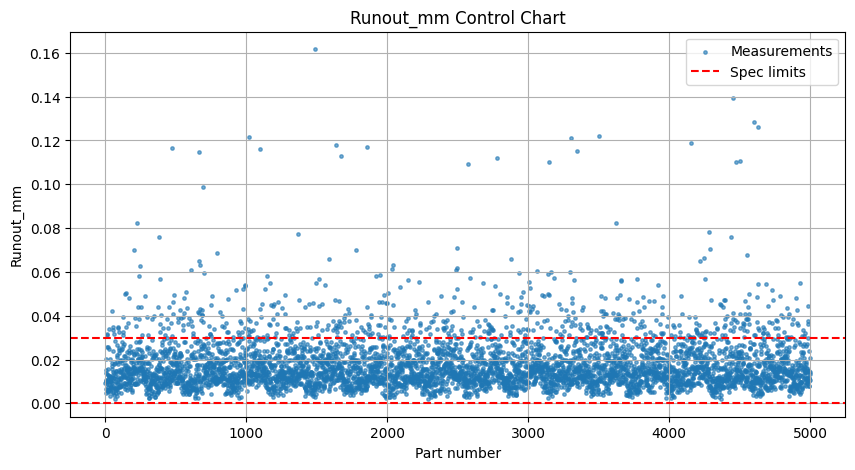

In [242]:
for i in specs_dict:
    create_control_chart(data, i, specs_dict[i][0], specs_dict[i][1], i + ' Control Chart')

C:\Users\brian\AppData\Local\Temp\ipykernel_4784\619130011.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(loc='upper right')


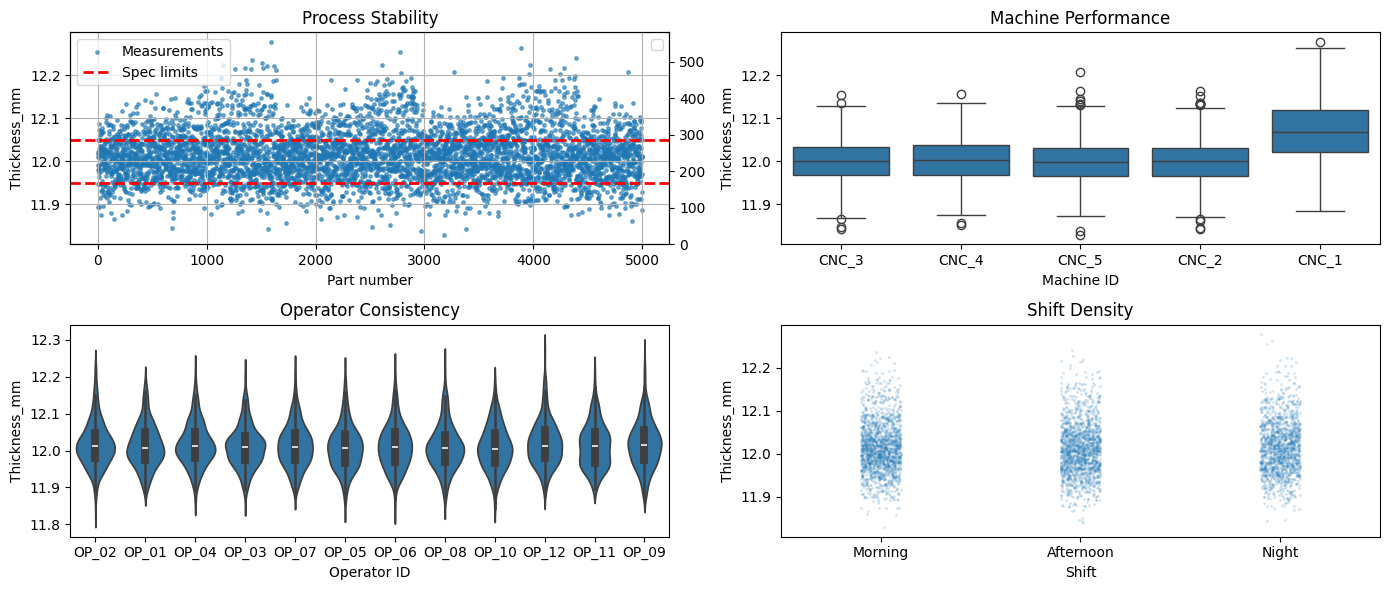

C:\Users\brian\AppData\Local\Temp\ipykernel_4784\619130011.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(loc='upper right')


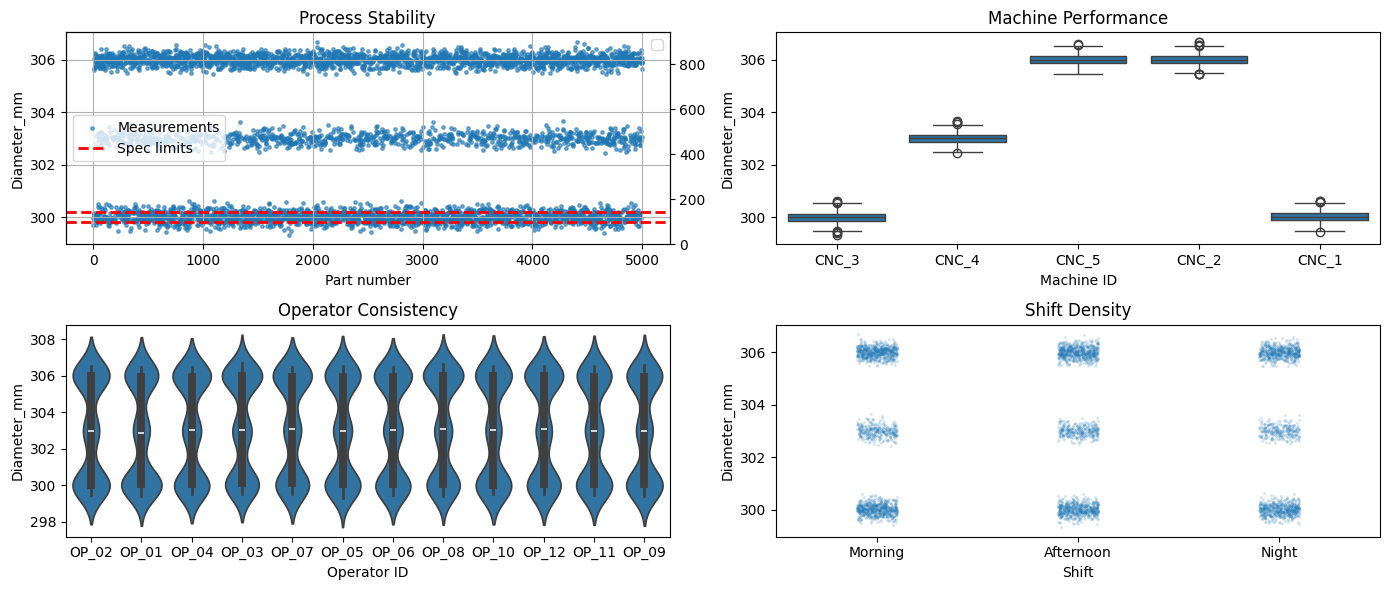

C:\Users\brian\AppData\Local\Temp\ipykernel_4784\619130011.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(loc='upper right')


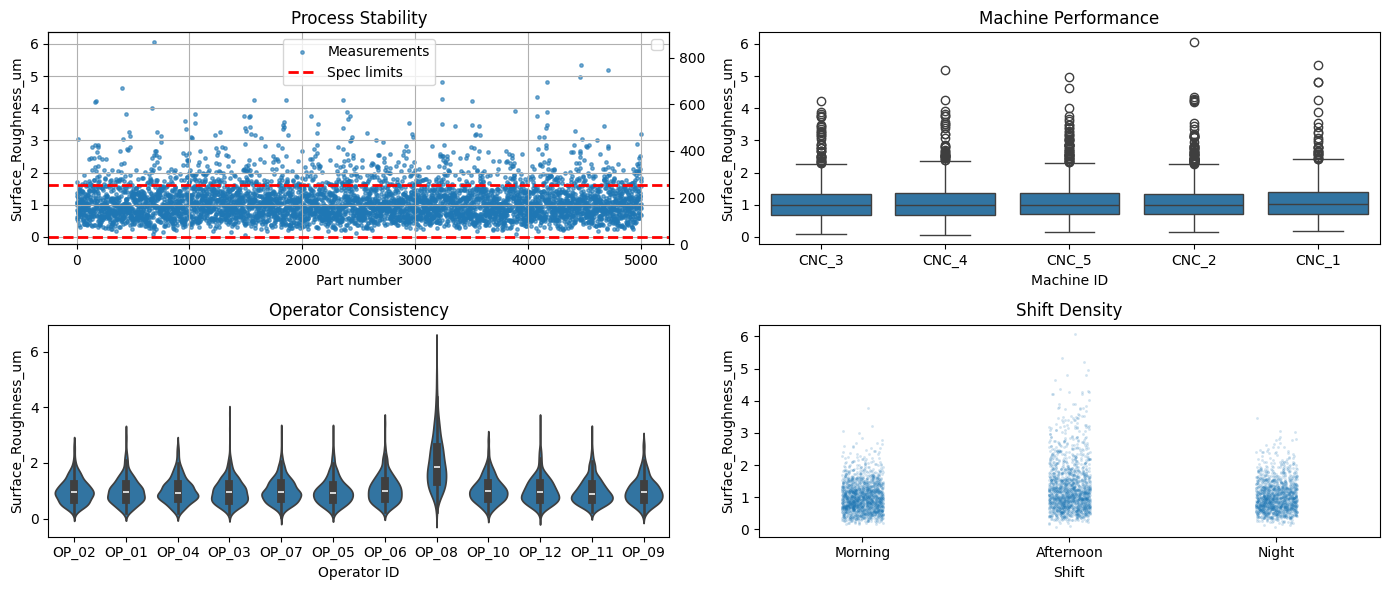

C:\Users\brian\AppData\Local\Temp\ipykernel_4784\619130011.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(loc='upper right')


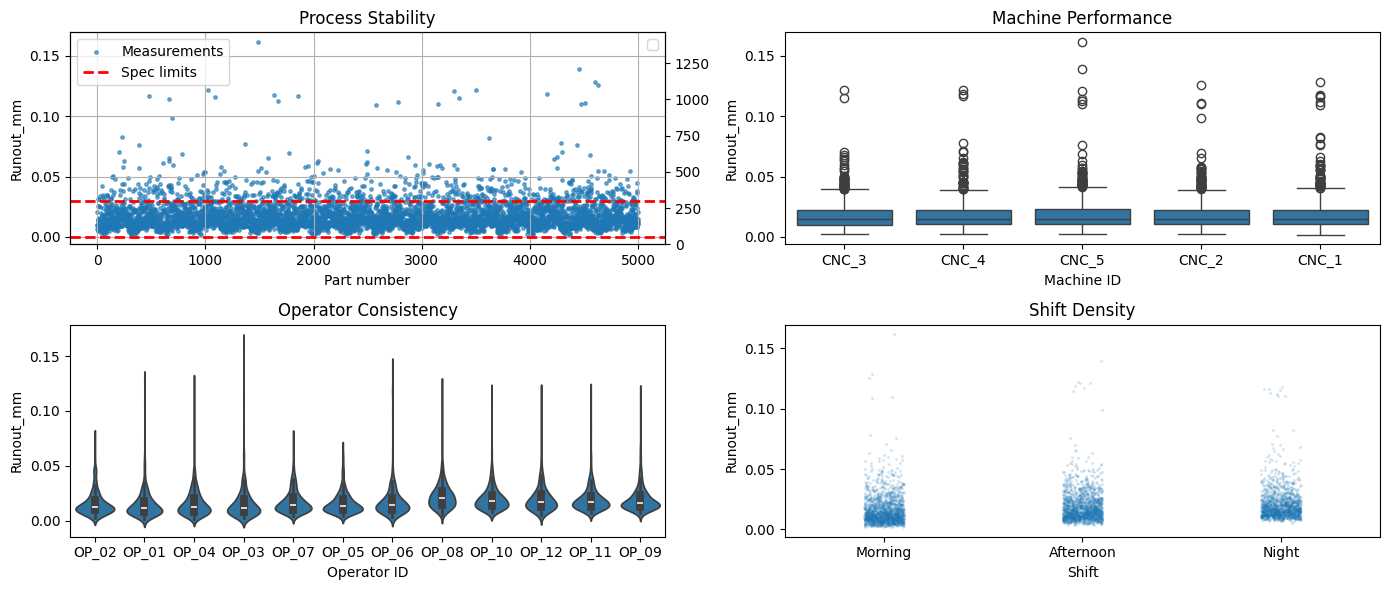

In [243]:
for i in specs_dict:
    create_measurement_analysis_dashboard(data, i, specs_dict[i])

Question 1  
Thickness and diameter show increasing trends, indicating gradual tool wear over the production run, while surface roughness and runout remain stable. The upward trends in thickness and diameter suggest cutting tools are becoming dull, removing slightly less material per part. Catching this early helps prevent out-of-spec parts at the end of the run.

Question 2  
Control charts show a small number of parts outside specification limits, mostly clustered toward the end of production for thickness and diameter. This clustering indicates that tools degrade over time and that preventive tool replacement should be scheduled before reaching the final parts. Surface roughness and runout have few out-of-spec points, consistent with a stable process.

Question 3  
The process stability plots for thickness and diameter show distributions slightly above their target values, indicating parts are slightly oversized. Adjusting tool offsets downward would recenter the distributions on 12.00 mm for thickness and 300.0 mm for diameter, improving conformity.

Question 4  
Box plots reveal that one machine has a slightly higher median surface roughness, suggesting calibration differences, while other machines are consistent. Violin plots show that certain operators produce wider distributions or multimodal patterns, indicating inconsistent techniques. Strip plots reveal that the night shift has tighter clustering, showing more consistent output than other shifts.

Question 5  
Top recommendations include replacing or sharpening worn cutting tools earlier to reduce trend-related defects, recalibrating the machine with higher median roughness, and providing targeted operator training for those producing inconsistent parts. Implementing these actions would reduce scrap, improve part quality, and stabilize production across shifts.

Question 6  
Comparing dashboards across measurements, Operator B and Machine 3 exhibit higher variability in multiple metrics, suggesting equipment and personnel issues are concentrated rather than widespread. A targeted intervention addressing the specific machine and operator would be more effective than general training for all staff.

The analysis revealed that thickness and diameter exhibit increasing trends due to tool wear, while surface roughness and runout remain stable. Certain machines and operators show higher variability, and specific shifts demonstrate more consistent output. Based on these findings, recommendations include proactive tool maintenance, targeted machine recalibration, and focused operator training to reduce defects and stabilize production. Implementing these measures will improve product quality, minimize scrap, and ensure adherence to manufacturing specifications.